LAB - 06
Feature Extraction and Machine Learning with Image and Text Data

In [1]:
import pandas as pd
import numpy as np

In [2]:
import cv2
import os
import time
import matplotlib as plt 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import( accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay)

In [3]:
IMAGE_DIR = "448"
print(os.listdir(IMAGE_DIR))

['Cracks', 'NonCracks']


In [4]:
print("Cracks:", len(os.listdir(os.path.join(IMAGE_DIR,"cracks"))))
print("Non-Cracks:", len(os.listdir(os.path.join(IMAGE_DIR,"noncracks"))))

Cracks: 200
Non-Cracks: 200


In [5]:
images = []
labels = []

crack_path = os.path.join(IMAGE_DIR,"cracks")

for file in os.listdir(crack_path):
    img = cv2.imread(os.path.join(crack_path, file))

    if img is not None:
        images.append(img)
        labels.append(1)

noncrack_path = os.path.join(IMAGE_DIR,"noncracks")

for file in os.listdir(noncrack_path):
    img = cv2.imread(os.path.join(noncrack_path, file))
    
    if img is not None:
        images.append(img)
        labels.append(0)

print("Total images:", len(images))
print("Total labels:", len(labels))

Total images: 400
Total labels: 400


In [6]:
print("First image shape:", images[0].shape)
print("First image height:", images[0].shape[0])
print("First image width:", images[0].shape[1])
print("Number of channels:", images[0].shape[2])

First image shape: (448, 448, 3)
First image height: 448
First image width: 448
Number of channels: 3


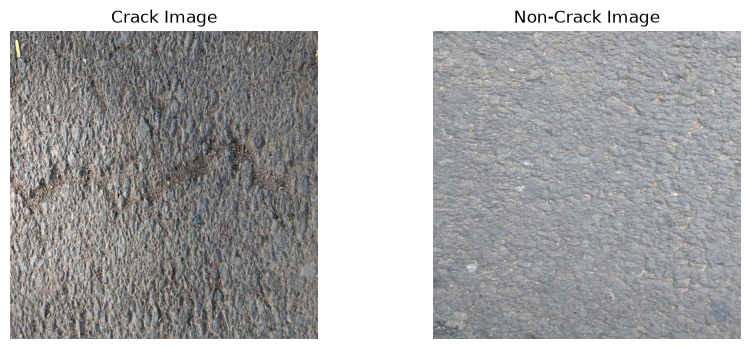

In [7]:
crack_image = cv2.cvtColor(images[0], cv2.COLOR_BGR2RGB)
noncrack_image = cv2.cvtColor(images[200], cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(crack_image)
plt.title("Crack Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(noncrack_image)
plt.title("Non-Crack Image")
plt.axis("off")

plt.show()

In [8]:
resized_images = []

for img in images:
    img = cv2.resize(img, (128, 128))
    resized_images.append(img)

print("Number of resized images:", len(resized_images))
print("New image shape:", resized_images[0].shape)

Number of resized images: 400
New image shape: (128, 128, 3)


In [9]:
features = []

for img in resized_images:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    mean_brightness = np.mean(gray)
    contrast = np.std(gray)

    dark_ratio = np.mean(gray < 50)
    bright_ratio = np.mean(gray > 200)

    features.append([
        mean_brightness,
        contrast,
        dark_ratio,
        bright_ratio
    ])

print("Number of feature rows:", len(features))

Number of feature rows: 400


In [10]:
#creating feature dataframe
feature_df = pd.DataFrame(
    features,
    columns=[
        "Mean_Brightness",
        "Contrast",
        "Dark_Pixel_Ratio",
        "Bright_Pixel_Ratio"
    ]
)

feature_df["Label"] = labels

feature_df.head()

,Mean_Brightness,Contrast,Dark_Pixel_Ratio,Bright_Pixel_Ratio,Label
0,122.263977,33.070752,0.005859,0.014465,1
1,131.565186,25.482184,0.003418,0.004456,1
2,121.076355,31.130490,0.014221,0.010498,1
3,130.309143,27.282676,0.002197,0.006592,1
4,130.993286,27.639562,0.003357,0.007751,1


In [11]:
#open cv canny edge detection

edge_features = []

for img in resized_images:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    edges = cv2.Canny(gray, 100, 200)

    edge_count = np.sum(edges > 0)
    edge_density = edge_count / edges.size

    edge_features.append([
        edge_count,
        edge_density
    ])

print("Edge features calculated:", len(edge_features))

Edge features calculated: 400


In [12]:
#adding canny features
edge_df = pd.DataFrame(
    edge_features,
    columns=[
        "Edge_Count",
        "Edge_Density"
    ]
)

feature_df["Edge_Count"] = edge_df["Edge_Count"]
feature_df["Edge_Density"] = edge_df["Edge_Density"]

feature_df.head

<bound method NDFrame.head of      Mean_Brightness   Contrast  Dark_Pixel_Ratio  Bright_Pixel_Ratio  Label  \
0         122.263977  33.070752          0.005859            0.014465      1   
1         131.565186  25.482184          0.003418            0.004456      1   
2         121.076355  31.130490          0.014221            0.010498      1   
3         130.309143  27.282676          0.002197            0.006592      1   
4         130.993286  27.639562          0.003357            0.007751      1   
..               ...        ...               ...                 ...    ...   
395       170.145630  17.648329          0.000000            0.046387      0   
396       170.866272  17.108084          0.000000            0.047424      0   
397       170.836914  17.604928          0.000000            0.050537      0   
398       167.012573  17.482031          0.000000            0.035034      0   
399       165.136719  17.661648          0.000000            0.030273      0   

     Edge

In [13]:
print("Feature dataset shape:", feature_df.shape)
print(feature_df.head())

feature_df.to_csv("crack_features.csv", index=False)

print("Feature dataset saved successfully.")

Feature dataset shape: (400, 7)
   Mean_Brightness   Contrast  Dark_Pixel_Ratio  Bright_Pixel_Ratio  Label  \
0       122.263977  33.070752          0.005859            0.014465      1   
1       131.565186  25.482184          0.003418            0.004456      1   
2       121.076355  31.130490          0.014221            0.010498      1   
3       130.309143  27.282676          0.002197            0.006592      1   
4       130.993286  27.639562          0.003357            0.007751      1   

   Edge_Count  Edge_Density  
0        5580      0.340576  
1        4579      0.279480  
2        4303      0.262634  
3        5507      0.336121  
4        5218      0.318481  
Feature dataset saved successfully.


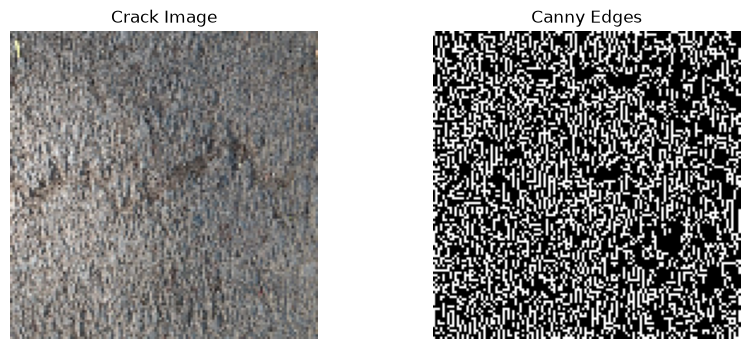

In [14]:
img = resized_images[0]

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, 100, 200)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Crack Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(edges, cmap="gray")
plt.title("Canny Edges")
plt.axis("off")

plt.show()

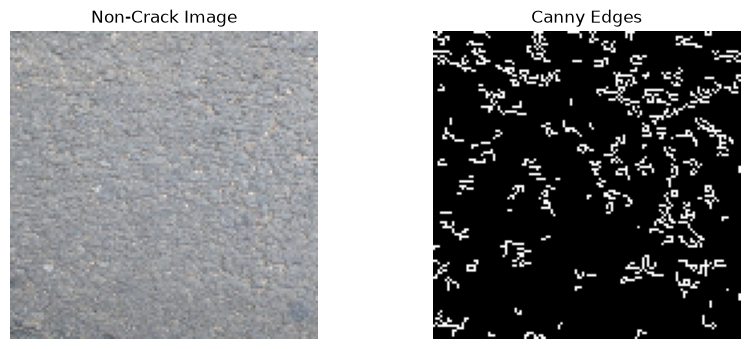

In [15]:
img = resized_images[200]

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, 100, 200)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Non-Crack Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(edges, cmap="gray")
plt.title("Canny Edges")
plt.axis("off")

plt.show()

In [16]:
X = feature_df.drop("Label", axis=1)
y = feature_df["Label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (400, 6)
y shape: (400,)


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 320
Testing samples: 80


In [18]:
logistic_model = LogisticRegression(max_iter=1000)

start_time = time.time()

logistic_model.fit(X_train, y_train)

train_time = time.time() - start_time

start_time = time.time()

logistic_predictions = logistic_model.predict(X_test)

prediction_time = time.time() - start_time

print("Training time:", train_time)
print("Prediction time:", prediction_time)

Training time: 0.04416251182556152
Prediction time: 0.0009353160858154297


In [19]:
logistic_accuracy = accuracy_score(y_test, logistic_predictions)
logistic_precision = precision_score(y_test, logistic_predictions)
logistic_recall = recall_score(y_test, logistic_predictions)
logistic_f1 = f1_score(y_test, logistic_predictions)

print("Logistic Regression")
print("Accuracy :", logistic_accuracy)
print("Precision:", logistic_precision)
print("Recall   :", logistic_recall)
print("F1 Score :", logistic_f1)

Logistic Regression
Accuracy : 0.625
Precision: 0.6041666666666666
Recall   : 0.725
F1 Score : 0.6590909090909091


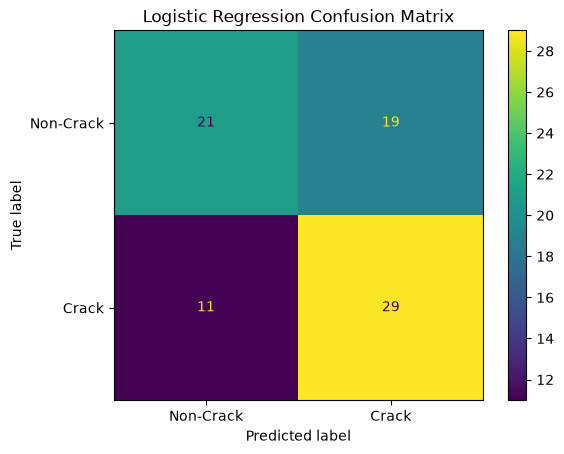

In [20]:
cm = confusion_matrix(y_test, logistic_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Crack", "Crack"]
)

disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [21]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

start_time = time.time()

random_forest.fit(X_train, y_train)

rf_train_time = time.time() - start_time

start_time = time.time()

rf_predictions = random_forest.predict(X_test)

rf_prediction_time = time.time() - start_time

print("Training time:", rf_train_time)
print("Prediction time:", rf_prediction_time)

Training time: 0.14050626754760742
Prediction time: 0.01424407958984375


In [22]:
rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions)
rf_recall = recall_score(y_test, rf_predictions)
rf_f1 = f1_score(y_test, rf_predictions)

print("Random Forest")
print("-------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

Random Forest
-------------
Accuracy : 0.9375
Precision: 0.9487179487179487
Recall   : 0.925
F1 Score : 0.9367088607594937


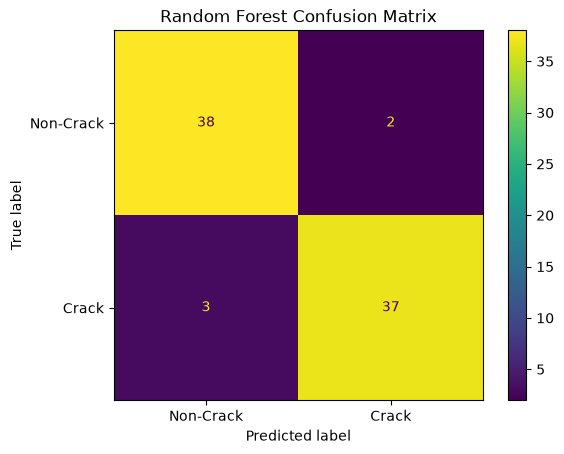

In [23]:
cm = confusion_matrix(y_test, rf_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Crack", "Crack"]
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

In [24]:
#comparing
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        rf_accuracy
    ],
    "Precision": [
        logistic_precision,
        rf_precision
    ],
    "Recall": [
        logistic_recall,
        rf_recall
    ],
    "F1 Score": [
        logistic_f1,
        rf_f1
    ],
    "Training Time": [
        train_time,
        rf_train_time
    ],
    "Prediction Time": [
        prediction_time,
        rf_prediction_time
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,Training Time,Prediction Time
0,Logistic Regression,0.6250,0.604167,0.725,0.659091,0.044163,0.000935
1,Random Forest,0.9375,0.948718,0.925,0.936709,0.140506,0.014244


In [25]:
results.to_csv("model_comparison.csv", index=False)

print("Model comparison saved successfully.")

Model comparison saved successfully.


PART B - TEXT VECTORIZATION AND SPAM CLASSIFICATION

In [26]:
import time
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [27]:
from sklearn.linear_model import LogisticRegression

In [28]:
df = pd.read_csv("emails.csv")

print(df.head())
print(df.shape)
print(df.columns)

  Email No.  the  to  ect  and  for  of    a  you  hou  ...  connevey  jay  \
0   Email 1    0   0    1    0    0   0    2    0    0  ...         0    0   
1   Email 2    8  13   24    6    6   2  102    1   27  ...         0    0   
2   Email 3    0   0    1    0    0   0    8    0    0  ...         0    0   
3   Email 4    0   5   22    0    5   1   51    2   10  ...         0    0   
4   Email 5    7   6   17    1    5   2   57    0    9  ...         0    0   

   valued  lay  infrastructure  military  allowing  ff  dry  Prediction  
0       0    0               0         0         0   0    0           0  
1       0    0               0         0         0   1    0           0  
2       0    0               0         0         0   0    0           0  
3       0    0               0         0         0   0    0           0  
4       0    0               0         0         0   1    0           0  

[5 rows x 3002 columns]
(5172, 3002)
Index(['Email No.', 'the', 'to', 'ect', 'and', 'f

In [29]:
print(df.isnull().sum())

Email No.     0
the           0
to            0
ect           0
and           0
             ..
military      0
allowing      0
ff            0
dry           0
Prediction    0
Length: 3002, dtype: int64


In [30]:
print(df["Prediction"].value_counts())

Prediction
0    3672
1    1500
Name: count, dtype: int64


In [40]:
word_columns = df.columns[1:-1]

def create_text(row):
    words = []

    for word in word_columns:
        count = int(row[word])

        if count > 0:
            words.extend([word] * count)

    return " ".join(words)

X = df[word_columns].apply(create_text, axis=1)
y = df["Prediction"]


In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [42]:
X_train

2588    to ect and and a a a a a a a a a a a a a a you...
2532    the the ect ect and for a a a a a a a a a a a ...
4500    the the the the to to ect for for for for a a ...
3597    the the the the the the the the the the the th...
2721    ect a a you be s e e can an t t j m b b o c c ...
                              ...                        
2639    the the the the the to to to ect ect ect ect e...
2126    to ect a a a in in in on on on i i i i i i i i...
3140    the to to to to to to ect ect ect a a a a a a ...
4582    the the the the the the the the the the the th...
856     the the the the the the the the the the the th...
Length: 4137, dtype: str

In [43]:
X_test

767     the the the the the to to ect ect ect for for ...
2650    the the to to to to to ect ect ect ect and and...
2568    the the the the the the to to to ect for for o...
3325    the the to to ect and and for of a a a a a a a...
5022    the the the the the to to to to to to to to to...
                              ...                        
1901    the the the the the the the to to to to ect ec...
1360    ect for a a i at s s s or hpl hpl hpl e e e e ...
1910    the to to ect of of a a a a a a you in on is i...
1847    the to to to to ect ect for a a a a a a a a a ...
1292    the the the to to ect ect and of of of a a a a...
Length: 1035, dtype: str

In [58]:
# Count Vectorization
vectorizer = CountVectorizer(
    lowercase=True,
    stop_words="english",  

)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("Number of features:", X_train_vec.shape[1])


Number of features: 2738


In [59]:
#logistic reggrression
model = LogisticRegression(max_iter=1000)
start_time = time.time()
model.fit(X_train_vec, y_train)
training_time = time.time() - start_time

In [60]:
start_time = time.time()
y_pred = model.predict(X_test_vec)
prediction_time = time.time() - start_time

In [61]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

In [62]:
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("Features :", X_train_vec.shape[1])
print("Training Time :", training_time)
print("Prediction Time:", prediction_time)

Accuracy : 0.9710144927536232
Precision: 0.9354838709677419
Recall   : 0.9666666666666667
F1 Score : 0.9508196721311475
Features : 2738
Training Time : 0.19650959968566895
Prediction Time: 0.0012042522430419922


Part C - Improve the Representation

In [63]:
improved_vectorizer = CountVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=2000

)

X_train_improved = improved_vectorizer.fit_transform(X_train)
X_test_improved = improved_vectorizer.transform(X_test)

print("Improved number of features:", X_train_improved.shape[1])

Improved number of features: 2000


In [64]:
improved_model = LogisticRegression(max_iter=1000)

start_time = time.time()

improved_model.fit(X_train_improved, y_train)

improved_training_time = time.time() - start_time

In [65]:
start_time = time.time()

y_pred_improved = improved_model.predict(X_test_improved)

improved_prediction_time = time.time() - start_time

In [66]:
improved_accuracy = accuracy_score(y_test, y_pred_improved)
improved_precision = precision_score(y_test, y_pred_improved)
improved_recall = recall_score(y_test, y_pred_improved)
improved_f1 = f1_score(y_test, y_pred_improved)

print("Improved Results")
print("Accuracy :", improved_accuracy)
print("Precision:", improved_precision)
print("Recall   :", improved_recall)
print("F1 Score :", improved_f1)
print("Features :", X_train_improved.shape[1])
print("Training Time :", improved_training_time)
print("Prediction Time:", improved_prediction_time)

Improved Results
Accuracy : 0.9719806763285024
Precision: 0.9385113268608414
Recall   : 0.9666666666666667
F1 Score : 0.9523809523809523
Features : 2000
Training Time : 0.2169938087463379
Prediction Time: 0.0017004013061523438


The representation was improved by limiting the vocabulary to 2000 features using max_features.
There is an improvement observed after the improvement steps. 
The fearures were reduced from 2738 to 2000.
It achieved the highest Accuracy 97.19% and F1-score 95.57% comparatied to previously before improvement.